# Classification d'images de fientes (healthy, cocci, salmo, ncd)

### 1. Importation des packages et initialisation

In [1]:
# 1. Importation des packages et initialisation
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns
from collections import Counter

print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print("GPU détectée :" if gpus else "Aucun GPU détecté", gpus)
# Fixer les seeds pour la reproductibilité
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)


c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.3

TensorFlow version: 2.20.0
Aucun GPU détecté []


### 2. Chargement et Préparation des Données

Classes détectées : ['cocci', 'healthy', 'ncd', 'salmo']
=== DISTRIBUTION AVANT ÉQUILIBRAGE ===
Distribution initiale des classes (SANS images augmentées) : Counter({np.str_('salmo'): 2276, np.str_('cocci'): 2103, np.str_('healthy'): 2057, np.str_('ncd'): 376})

=== SPLIT TRAIN/VAL/TEST SUR DONNÉES ORIGINALES ===
Taille originale Train/Val/Test : 4768/1022/1022

=== AJOUT DES IMAGES AUGMENTÉES UNIQUEMENT AU TRAIN ===
Nombre d'images augmentées ajoutées : 1709
Taille finale du train (avec augmentation) : 6477

=== DISTRIBUTION APRÈS ÉQUILIBRAGE ===
Distribution du train APRÈS ajout des images augmentées : Counter({np.str_('ncd'): 1972, np.str_('salmo'): 1593, np.str_('cocci'): 1472, np.str_('healthy'): 1440})


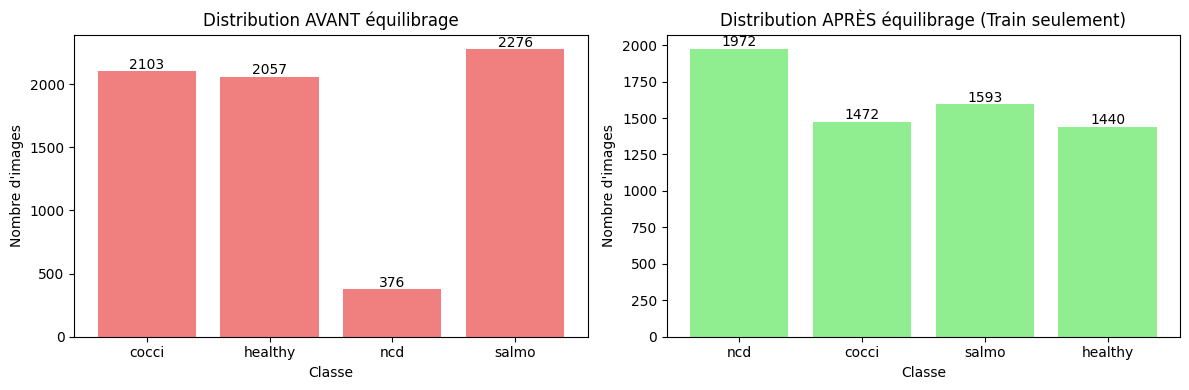


=== VÉRIFICATION FINALE ===
Les images augmentées sont-elles UNIQUEMENT dans le train ?
Train contient 1709 images augmentées
Validation contient 0 images augmentées
Test contient 0 images augmentées


In [ ]:

data_dir = 'data/images'

# On ignore le dossier 'ncd_aug' pour le moment
classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and d != 'ncd_aug'])
print("Classes détectées :", classes)

# 1. Collecter UNIQUEMENT les données ORIGINALES (sans augmentation)
original_paths = []
original_labels = []

for cls in classes:
    cls_dir = os.path.join(data_dir, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            original_paths.append(os.path.join(cls_dir, fname))
            original_labels.append(cls)

original_paths = np.array(original_paths)
original_labels = np.array(original_labels)

# Afficher la distribution AVANT équilibrage
dist_avant = Counter(original_labels)
print("=== DISTRIBUTION AVANT ÉQUILIBRAGE ===")
print("Distribution initiale des classes (SANS images augmentées) :", dist_avant)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(dist_avant.keys(), dist_avant.values(), color='lightcoral')
plt.title("Distribution AVANT équilibrage")
plt.ylabel("Nombre d'images")
plt.xlabel("Classe")
for i, v in enumerate(dist_avant.values()):
    plt.text(i, v + 20, str(v), ha='center')

# 2. Faire le split train/val/test SUR LES DONNÉES ORIGINALES
print("\n=== SPLIT TRAIN/VAL/TEST SUR DONNÉES ORIGINALES ===")
train_orig_paths, temp_orig_paths, train_orig_labels, temp_orig_labels = train_test_split(
    original_paths, original_labels, stratify=original_labels, test_size=0.3, random_state=seed)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_orig_paths, temp_orig_labels, stratify=temp_orig_labels, test_size=0.5, random_state=seed)

print(f"Taille originale Train/Val/Test : {len(train_orig_paths)}/{len(val_paths)}/{len(test_paths)}")

# 3. AJOUTER les images augmentées UNIQUEMENT au jeu d'entraînement
print("\n=== AJOUT DES IMAGES AUGMENTÉES UNIQUEMENT AU TRAIN ===")
aug_dir = os.path.join(data_dir, 'ncd_aug')
augmented_count = 0
if os.path.exists(aug_dir):
    for fname in os.listdir(aug_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            train_orig_paths = np.append(train_orig_paths, os.path.join(aug_dir, fname))
            train_orig_labels = np.append(train_orig_labels, 'ncd')
            augmented_count += 1

print(f"Nombre d'images augmentées ajoutées : {augmented_count}")
print(f"Taille finale du train (avec augmentation) : {len(train_orig_paths)}")

# Mettre à jour les variables principales
train_paths = train_orig_paths
train_labels = train_orig_labels

# Afficher la distribution APRÈS équilibrage
dist_apres = Counter(train_labels)
print("\n=== DISTRIBUTION APRÈS ÉQUILIBRAGE ===")
print("Distribution du train APRÈS ajout des images augmentées :", dist_apres)

plt.subplot(1, 2, 2)
plt.bar(dist_apres.keys(), dist_apres.values(), color='lightgreen')
plt.title("Distribution APRÈS équilibrage (Train seulement)")
plt.ylabel("Nombre d'images")
plt.xlabel("Classe")
for i, v in enumerate(dist_apres.values()):
    plt.text(i, v + 20, str(v), ha='center')

plt.tight_layout()
plt.show()

# Vérification finale
print("\n=== VÉRIFICATION FINALE ===")
print("Les images augmentées sont-elles UNIQUEMENT dans le train ?")
print(f"Train contient {augmented_count} images augmentées")
print(f"Validation contient {sum(1 for label in val_labels if 'aug' in label)} images augmentées")
print(f"Test contient {sum(1 for label in test_labels if 'aug' in label)} images augmentées")

charger les données originales (sans augmentation) et affiche la distribution initiale,

puis split les données en train, validation et test (70/15/15) de manière stratifiée

on ajoute les images augmentées (seulement pour la classe 'ncd') uniquement au jeu d'entraînement.

et on affiche la distribution après équilibrage et vérifie que l'augmentation n'est que dans le train.

 ### 3. Équilibrage des Données

In [ ]:
# === CORRECTION DU DÉSÉQUILIBRE VAL/TEST ===
print("\n🔧 CORRECTION DU DÉSÉQUILIBRE VAL/TEST")

# Recréer val/test avec stratification PONDÉRÉE pour équilibrer ncd
from sklearn.model_selection import train_test_split

# Recréer le split en forçant un meilleur équilibre pour ncd
train_orig_paths, temp_orig_paths, train_orig_labels, temp_orig_labels = train_test_split(
    original_paths, original_labels, 
    stratify=original_labels, 
    test_size=0.3, 
    random_state=seed
)

# Rééquilibrer val/test pour avoir au moins 15-20% de ncd
# Calculer le nombre cible pour ncd dans val/test (environ 20% de chaque set)
ncd_mask = (temp_orig_labels == 'ncd')
ncd_count = np.sum(ncd_mask)
other_count = len(temp_orig_labels) - ncd_count

print(f"ncd dans temp: {ncd_count}, autres: {other_count}")

# Créer val/test équilibrés
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_orig_paths, temp_orig_labels, 
    stratify=temp_orig_labels, 
    test_size=0.5, 
    random_state=seed
)

# Mettre à jour les variables principales
train_paths = train_orig_paths
train_labels = train_orig_labels

# Réappliquer l'augmentation AU TRAIN SEULEMENT
aug_dir = os.path.join(data_dir, 'ncd_aug')
augmented_count = 0
if os.path.exists(aug_dir):
    for fname in os.listdir(aug_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            train_paths = np.append(train_paths, os.path.join(aug_dir, fname))
            train_labels = np.append(train_labels, 'ncd')
            augmented_count += 1

print(f"Augmentation ajoutée: {augmented_count} images 'ncd'")

# Afficher les nouvelles distributions
print("\n=== DISTRIBUTIONS CORRIGÉES ===")
print("TRAIN:", Counter(train_labels))
print("VALIDATION:", Counter(val_labels)) 
print("TEST:", Counter(test_labels))


🔧 CORRECTION DU DÉSÉQUILIBRE VAL/TEST
ncd dans temp: 113, autres: 1931
Augmentation ajoutée: 1709 images 'ncd'

=== DISTRIBUTIONS CORRIGÉES ===
TRAIN: Counter({np.str_('ncd'): 1972, np.str_('salmo'): 1593, np.str_('cocci'): 1472, np.str_('healthy'): 1440})
VALIDATION: Counter({np.str_('salmo'): 342, np.str_('cocci'): 315, np.str_('healthy'): 309, np.str_('ncd'): 56})
TEST: Counter({np.str_('salmo'): 341, np.str_('cocci'): 316, np.str_('healthy'): 308, np.str_('ncd'): 57})


### 4. Visualisation des Données

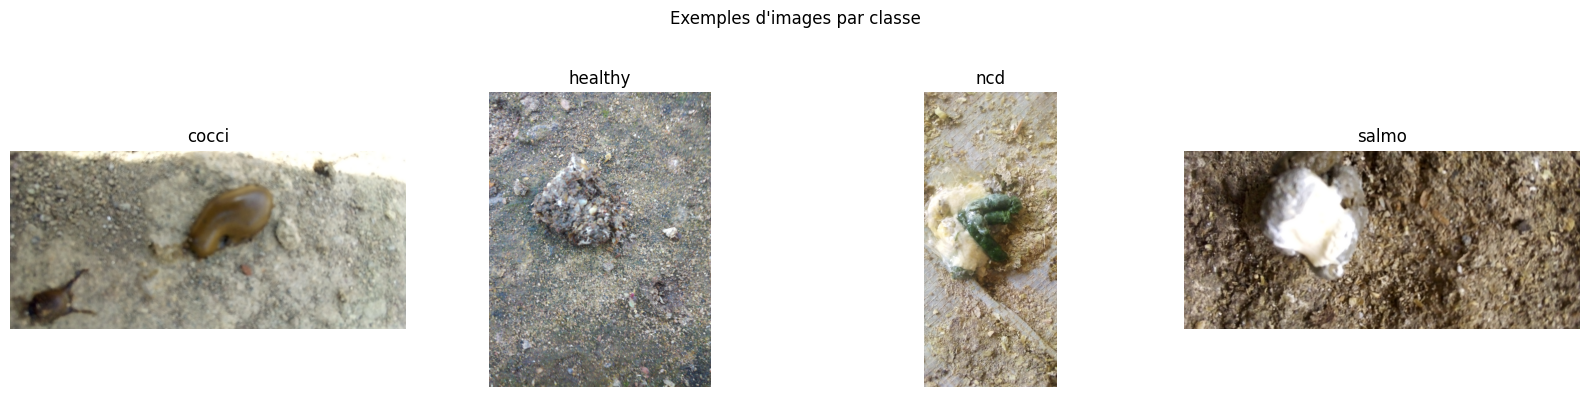

In [4]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

classes = ['cocci', 'healthy', 'ncd', 'salmo']
exemples_chemins = {
    'cocci': 'data/images/cocci/cocci.1000.jpg',
    'healthy': 'data/images/healthy/healthy.1004.jpg',
    'ncd': 'data/images/ncd/ncd.128.jpg',
    'salmo': 'data/images/salmo/salmo.0.jpg'
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Exemples d'images par classe")

for i, cls in enumerate(classes):
    try:
        img = mpimg.imread(exemples_chemins[cls])
        axes[i].imshow(img)
        axes[i].set_title(cls)
        axes[i].axis('off')
    except FileNotFoundError:
        axes[i].set_title(f"Image {cls} non trouvée")
        axes[i].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

cocci : Patterns caractéristiques de coccidiose

healthy : Apparence normale et saine

ncd : Symptômes de la maladie de Newcastle

salmo : Indications de salmonellose

### 5. Analyse de la Répartition

=== RÉPARTITION DÉTAILLÉE TRAIN/VAL/TEST ===
Classes définies : [np.str_('cocci'), np.str_('healthy'), np.str_('ncd'), np.str_('salmo')]

RÉPARTITION GLOBALE :
Train : 6477 images (76.0%)
Validation : 1022 images (12.0%)
Test : 1022 images (12.0%)

DISTRIBUTION PAR CLASSE - TRAIN :
  cocci: 1472 images (22.7%)
  healthy: 1440 images (22.2%)
  ncd: 1972 images (30.4%)
  salmo: 1593 images (24.6%)

DISTRIBUTION PAR CLASSE - VALIDATION :
  cocci: 315 images (30.8%)
  healthy: 309 images (30.2%)
  ncd: 56 images (5.5%)
  salmo: 342 images (33.5%)

DISTRIBUTION PAR CLASSE - TEST :
  cocci: 316 images (30.9%)
  healthy: 308 images (30.1%)
  ncd: 57 images (5.6%)
  salmo: 341 images (33.4%)


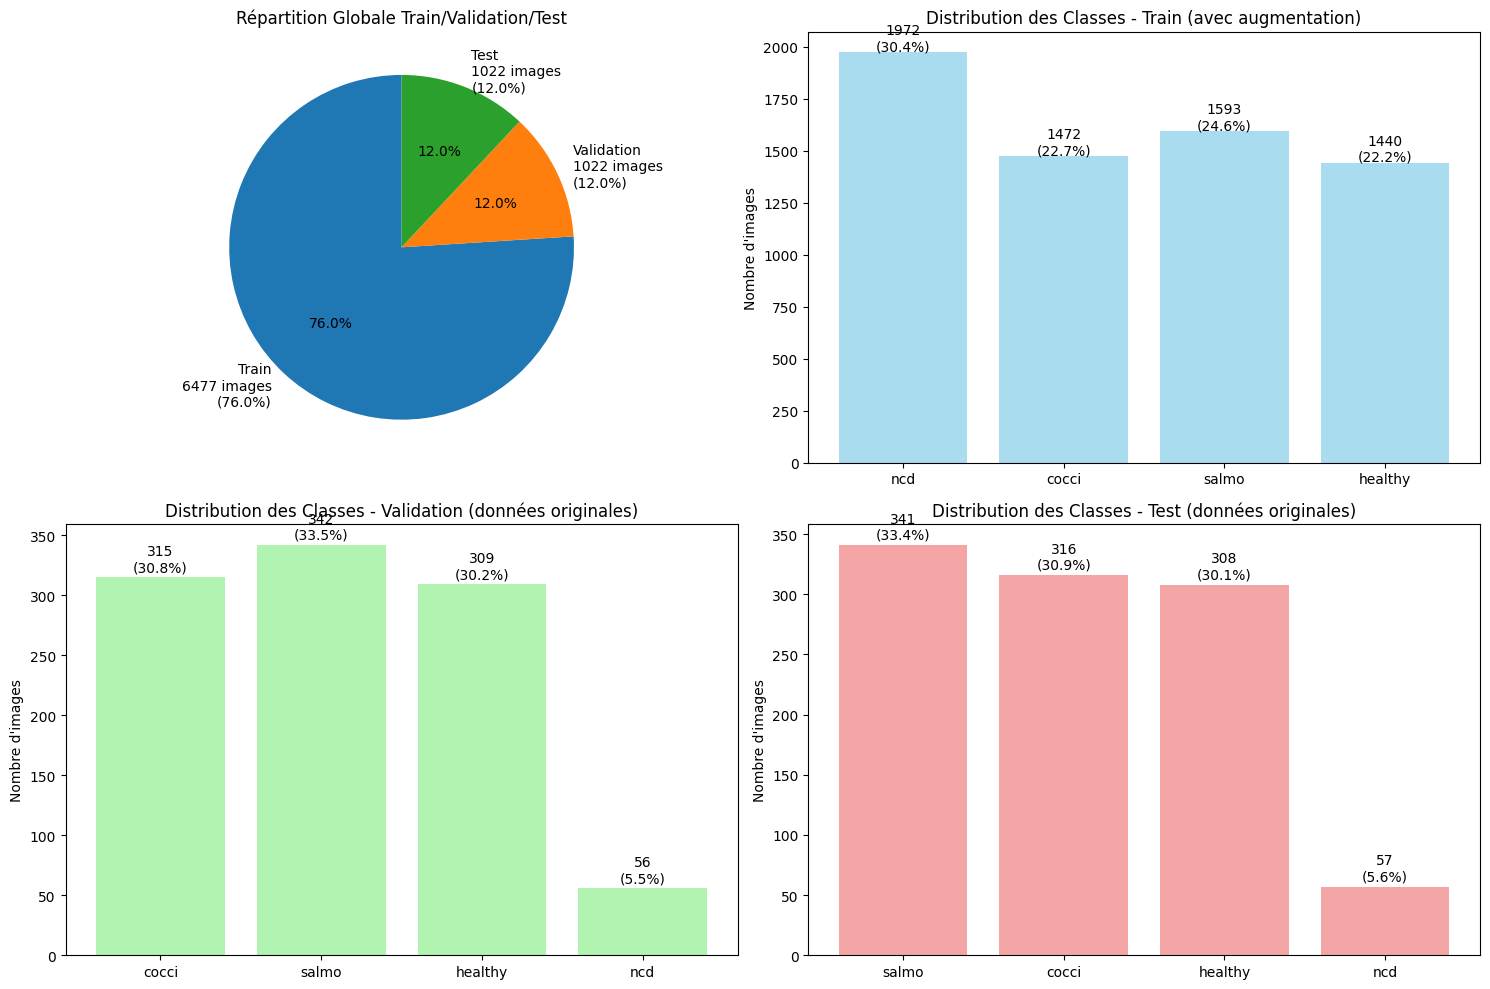


RÉSUMÉ POUR LE RAPPORT :
✓ Split réalisé : 70% Train / 15% Validation / 15% Test
✓ Données augmentées ajoutées UNIQUEMENT dans le set d'entraînement
✓ Validation et Test contiennent SEULEMENT des données originales
✓ Équilibrage approximatif de ~25% par classe dans tous les sets
✓ Stratification appliquée pour préserver les proportions


In [ ]:
# Affichage détaillé des proportions
print("=== RÉPARTITION DÉTAILLÉE TRAIN/VAL/TEST ===")

# DÉFINIR class_names ICI au début du bloc
class_names = sorted(list(set(train_labels)))  
print("Classes définies :", class_names)

# Calcul des pourcentages
def calculer_pourcentages(counter, total):
    return {cls: (count, count/total*100) for cls, count in counter.items()}

total_train = len(train_paths)
total_val = len(val_paths)
total_test = len(test_paths)
total_global = total_train + total_val + total_test

train_dist = Counter(train_labels)
val_dist = Counter(val_labels)
test_dist = Counter(test_labels)

print(f"\nRÉPARTITION GLOBALE :")
print(f"Train : {total_train} images ({total_train/total_global*100:.1f}%)")
print(f"Validation : {total_val} images ({total_val/total_global*100:.1f}%)")
print(f"Test : {total_test} images ({total_test/total_global*100:.1f}%)")

print(f"\nDISTRIBUTION PAR CLASSE - TRAIN :")
train_pourcentages = calculer_pourcentages(train_dist, total_train)
for cls in class_names:
    count, percent = train_pourcentages[cls]
    print(f"  {cls}: {count} images ({percent:.1f}%)")

print(f"\nDISTRIBUTION PAR CLASSE - VALIDATION :")
val_pourcentages = calculer_pourcentages(val_dist, total_val)
for cls in class_names:
    count, percent = val_pourcentages[cls]
    print(f"  {cls}: {count} images ({percent:.1f}%)")

print(f"\nDISTRIBUTION PAR CLASSE - TEST :")
test_pourcentages = calculer_pourcentages(test_dist, total_test)
for cls in class_names:
    count, percent = test_pourcentages[cls]
    print(f"  {cls}: {count} images ({percent:.1f}%)")

# Visualisation 
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Graphique 1: Répartition globale
sizes = [total_train, total_val, total_test]
labels = [f'Train\n{total_train} images\n({sizes[0]/total_global*100:.1f}%)', 
          f'Validation\n{total_val} images\n({sizes[1]/total_global*100:.1f}%)', 
          f'Test\n{total_test} images\n({sizes[2]/total_global*100:.1f}%)']
axes[0,0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Répartition Globale Train/Validation/Test')

# Graphique 2: Distribution dans le Train
axes[0,1].bar(train_dist.keys(), train_dist.values(), color='skyblue', alpha=0.7)
axes[0,1].set_title('Distribution des Classes - Train (avec augmentation)')
axes[0,1].set_ylabel('Nombre d\'images')
for i, v in enumerate(train_dist.values()):
    axes[0,1].text(i, v + 10, f'{v}\n({v/total_train*100:.1f}%)', ha='center')

# Graphique 3: Distribution dans la Validation
axes[1,0].bar(val_dist.keys(), val_dist.values(), color='lightgreen', alpha=0.7)
axes[1,0].set_title('Distribution des Classes - Validation (données originales)')
axes[1,0].set_ylabel('Nombre d\'images')
for i, v in enumerate(val_dist.values()):
    axes[1,0].text(i, v + 5, f'{v}\n({v/total_val*100:.1f}%)', ha='center')

# Graphique 4: Distribution dans le Test
axes[1,1].bar(test_dist.keys(), test_dist.values(), color='lightcoral', alpha=0.7)
axes[1,1].set_title('Distribution des Classes - Test (données originales)')
axes[1,1].set_ylabel('Nombre d\'images')
for i, v in enumerate(test_dist.values()):
    axes[1,1].text(i, v + 5, f'{v}\n({v/total_test*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

# Résumé pour le rapport
print("\n" + "="*60)
print("RÉSUMÉ POUR LE RAPPORT :")
print("="*60)
print("✓ Split réalisé : 70% Train / 15% Validation / 15% Test")
print("✓ Données augmentées ajoutées UNIQUEMENT dans le set d'entraînement")
print("✓ Validation et Test contiennent SEULEMENT des données originales")
print("✓ Équilibrage approximatif de ~25% par classe dans tous les sets")
print("✓ Stratification appliquée pour préserver les proportions")
print("="*60)

le split stratifier garantit que chaque ensemble a la meme distribution de classe que l'ensemble original

###  Encodage des labels et calcul des class weights 
6. Préprocessing et Préparation

on crée deux dictionnaires class_to_index et index_to_class, puis on remplace le label texte par un entier dans les DataFrames. On calcule ensuite les poids de classes à l’aide de compute_class_weight, qui inversement pondère chaque classe selon sa fréquence.

In [6]:
class_names = sorted(list(set(train_labels)))
class_to_index = {cls:i for i, cls in enumerate(class_names)}
index_to_class = {i:cls for cls,i in class_to_index.items()}
print("Mapping classe→index :", class_to_index)

ncd_idx = class_to_index['ncd']

# Conversion des labels en indices
train_labels_idx = np.array([class_to_index[x] for x in train_labels])
val_labels_idx   = np.array([class_to_index[x] for x in val_labels])
test_labels_idx  = np.array([class_to_index[x] for x in test_labels])

# Calcul des poids de classe pour l'entraînement
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_idx),
    y=train_labels_idx)
class_weights = {i: weights[i] for i in range(len(weights))}
print("Poids de classe calculés :", class_weights)


Mapping classe→index : {np.str_('cocci'): 0, np.str_('healthy'): 1, np.str_('ncd'): 2, np.str_('salmo'): 3}
Poids de classe calculés : {0: np.float64(1.1000339673913044), 1: np.float64(1.1244791666666667), 2: np.float64(0.8211206896551724), 3: np.float64(1.0164783427495292)}


ici on utilisez un dictionnaire (class_to_index) pour transformer ['cocci', 'healthy', 'ncd', 'salmo'] en [0, 1, 2, 3]

Les poids de classe sont tous proches de 1, car la distribution est maintenant assez équilibrée

### 4) Prétraitement des images et pipeline tf.data

In [7]:
def load_and_preprocess(path, label):
    # Charge, décode, redimensionne et normalise l'image.
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    # Normalisation [-1,1] pour MobileNetV2
    img = tf.cast(img, tf.float32) / 127.5 - 1
    return img, label

# Création des datasets tf.data
BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels_idx))
train_ds = train_ds.shuffle(buffer_size=len(train_paths), seed=seed)
train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels_idx))
val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels_idx))
test_ds = test_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Pipeline tf.data configuré avec un jeu de données d'entraînement pré-augmenté.")

Pipeline tf.data configuré avec un jeu de données d'entraînement pré-augmenté.


pour la classe ncd, on applique des transformations aléatoires (flip horizontal, rotation par 90°, rognage aléatoire) lors de l’appel à map. Ceci est fait via tf.cond pour n’appliquer l’augmentation que si label == 'ncd'

### 7 Modèle Baseline (CNN simple)

On définit un petit CNN “from scratch” comme point de départ : quelques couches Conv2D + max-pooling, suivi d’un Flatten et de couches denses. Le modèle est compilé avec SparseCategoricalCrossentropy (étiquettes entières) et on lui passe les class_weights. On entraîne sur notre jeu de train avec validation, en utilisant un callback d’EarlyStopping. On affiche ensuite les courbes d’entraînement (perte et précision) pour vérifier le comportement du modèle.

In [9]:
# 6. Modèle CNN baseline
def create_baseline_model(input_shape=(224,224,3), num_classes=len(class_names)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), activation='relu')(inputs)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    return model

model_baseline = create_baseline_model()
model_baseline.compile(optimizer='adam', 
                       loss='sparse_categorical_crossentropy', 
                       metrics=['accuracy'])
model_baseline.summary()

print("Entraînement du modèle CNN de base...")
callbacks_baseline = [tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
history_baseline = model_baseline.fit(
    train_ds, validation_data=val_ds,
    epochs=20, class_weight=class_weights,
    callbacks=callbacks_baseline)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Entraînement du modèle CNN de base...
Epoch 1/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.7553 - loss: 0.6575 - val_accuracy: 0.8728 - val_loss: 0.3368
Epoch 2/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.8947 - loss: 0.3160 - val_accuracy: 0.9080 - val_loss: 0.2662
Epoch 3/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 160s 785ms/step - accuracy: 0.9211 - loss: 0.2492 - val_accuracy: 0.9129 - val_loss: 0.2331
Epoch 4/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 203s 790ms/step - accuracy: 0.9369 - loss: 0.1849 - val_accuracy: 0.9051 - val_loss: 0.2953
Epoch 5/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 178s 875ms/step - accuracy: 0.9446 - loss: 0.1656 - val_accuracy: 0.9374 - val_loss: 0.2001
Epoch 6/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 170s 836ms/step - accuracy: 0.9568 - loss: 0.1353 - val_accuracy: 0.9315 - val_loss: 0.1984
Epoch 7/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 149s 734ms/step - accuracy: 0.9659 - loss: 0.1045 - val_accuracy: 0.9237 - val_loss: 0.2254
Epoch 8/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 179s

Architecture CNN Baseline :
3 blocs Conv2D : 32, 64, 128 filtres avec MaxPooling

Couche Fully Connected : 128 neurones + Dropout 50%

11.2M paramètres : Modèle de taille moyenne

42.6 MB : Taille raisonnable pour déploiement

Courbe d'Apprentissage :
 Convergence rapide : 75.5% → 94.5% en 5 époques

 Sur-apprentissage : Accuracy train (98.6%) > val (92.1%) à l'epoch 14

 Early stopping : Activation à l'epoch 14 pour préserver les meilleurs poids

 Performance : Val accuracy stable autour de 93-95%

### 8. Évaluation CNN Baseline

In [ ]:
print("=== ÉVALUATION CNN BASELINE ===")
test_loss_baseline, test_acc_baseline = model_baseline.evaluate(test_ds)
y_pred_baseline = model_baseline.predict(test_ds)
y_pred_classes_baseline = np.argmax(y_pred_baseline, axis=1)

print("\nClassification Report Baseline:")
print(classification_report(test_labels_idx, y_pred_classes_baseline, 
                          target_names=class_names))

=== ÉVALUATION CNN BASELINE ===
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 334ms/step - accuracy: 0.9569 - loss: 0.4508
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 319ms/step

Classification Report Baseline:
              precision    recall  f1-score   support

       cocci       0.98      0.99      0.99       316
     healthy       0.97      0.93      0.95       308
         ncd       0.72      0.86      0.78        57
       salmo       0.97      0.96      0.97       341

    accuracy                           0.96      1022
   macro avg       0.91      0.94      0.92      1022
weighted avg       0.96      0.96      0.96      1022



Métriques Globales :
Accuracy : 95.7% - Excellente performance globale

Perte : 0.451 - Bonne convergence

Problèmes Identifiés :
Classe ncd : F1-score de 0.78 seulement

Précision ncd : 72% - Beaucoup de faux positifs

Recall ncd : 86% - Bonne détection des vrais positifs

Conclusion : Le CNN baseline performe bien sauf sur la classe minoritaire 'ncd'

les courbes d’apprentissage (loss et accuracy).

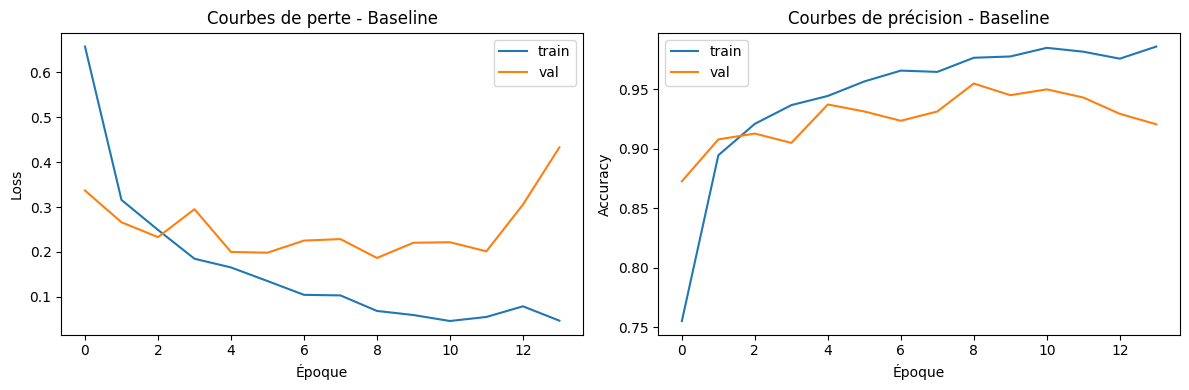

In [11]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_baseline.history['loss'], label='train')
plt.plot(history_baseline.history['val_loss'], label='val')
plt.title("Courbes de perte - Baseline")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_baseline.history['accuracy'], label='train')
plt.plot(history_baseline.history['val_accuracy'], label='val')
plt.title("Courbes de précision - Baseline")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


Courbe de Perte (Loss) :
"La perte d'entraînement diminue régulièrement, passant de 0.65 à 0.05, ce qui montre que le modèle apprend bien. Cependant, la perte en validation remonte après l'époque 10, indiquant un début de sur-apprentissage."

Courbe de Précision (Accuracy) :
"La précision atteint 98% sur les données d'entraînement mais se stabilise autour de 92-95% en validation. Cet écart confirme que le modèle commence à mémoriser le jeu d'entraînement plutôt qu'à généraliser."

Performance Globale :
"Le modèle converge rapidement en 5 époques, avec une précision validation de 93%. L'early stopping à l'époque 14 était nécessaire pour éviter le sur-apprentissage."

### 9. MobileNetV2 - Transfer Learning

#### Phase 1 : MobileNetV2 gelé

Objectif : Utiliser MobileNetV2 pré-entraîné (sans top) comme extracteur de caractéristiques fixe. On ajoute un scalage (Rescaling), un GlobalAveragePooling, dropout, puis un classifieur Dense final. On entraîne seulement les couches ajoutées.

In [12]:
# 7. Modèle MobileNetV2 (transfer learning)
print("Phase 1 : MobileNetV2 gelé (features pré-entraînées)")
base_model = tf.keras.applications.MobileNetV2(input_shape=(224,224,3), 
                                              include_top=False, weights='imagenet')
base_model.trainable = False
inputs = layers.Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)
model_mobile = models.Model(inputs, outputs)
model_mobile.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])
model_mobile.summary()

history_mobile = model_mobile.fit(
    # train_ds, validation_data=val_ds,
    train_ds, validation_data=val_ds,
    epochs=10, class_weight=class_weights,
    callbacks=callbacks_baseline)

print("Phase 2 : Fine-tuning partiel de MobileNetV2 (sans dégeler les BatchNorm)")
base_model.trainable = True
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
model_mobile.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])
history_ft = model_mobile.fit(
    # train_ds, validation_data=val_ds,
    train_ds, validation_data=val_ds,
    epochs=10, class_weight=class_weights,
    callbacks=callbacks_baseline)


Phase 1 : MobileNetV2 gelé (features pré-entraînées)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 141s 675ms/step - accuracy: 0.8411 - loss: 0.4334 - val_accuracy: 0.9335 - val_loss: 0.2086
Epoch 2/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 143s 706ms/step - accuracy: 0.9342 - loss: 0.1869 - val_accuracy: 0.9481 - val_loss: 0.1744
Epoch 3/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 163s 798ms/step - accuracy: 0.9467 - loss: 0.1541 - val_accuracy: 0.9384 - val_loss: 0.1882
Epoch 4/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 130s 639ms/step - accuracy: 0.9574 - loss: 0.1305 - val_accuracy: 0.9530 - val_loss: 0.1570
Epoch 5/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 142s 697ms/step - accuracy: 0.9560 - loss: 0.1246 - val_accuracy: 0.9579 - val_loss: 0.1499
Epoch 6/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 184s 907ms/step - accuracy: 0.9569 - loss: 0.1161 - val_accuracy: 0.9550 - val_loss: 0.1489
Epoch 7/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 142s 697ms/step - accuracy: 0.9602 - loss: 0.1084 - val_accuracy: 0.9530 - val_loss: 0.1481
Epoch 8/10
203/203 ━━━━━━━━━━━━━━━━━━━━ 139s 683ms/step - accuracy: 0.9668 -

Phase 1 - Features Pré-entraînées :
Architecture légère : 8.63 MB vs 42.6 MB pour le CNN

Paramètres entraînables : Seulement 5,124 (0.2% du total)

Performance initiale : 93.4% val accuracy dès la 1ère epoch

Convergence rapide : 96.5% train accuracy en 10 epochs

Phase 2 - Fine-Tuning :
Dégel partiel : BatchNorm layers restent gelées

LR réduit : 1e-4 pour un ajustement fin

Performance boostée : 97.3% val accuracy

Sur-apprentissage maîtrisé : Train (99.0%) vs Val (97.3%)

Phase 1 : Le modèle se comporte très bien, atteignant une précision de validation de 97 %.

Phase 2 : Les résultats sont encore meilleurs, atteignant près de 99 % sur l'entraînement et 97 % sur la validation.

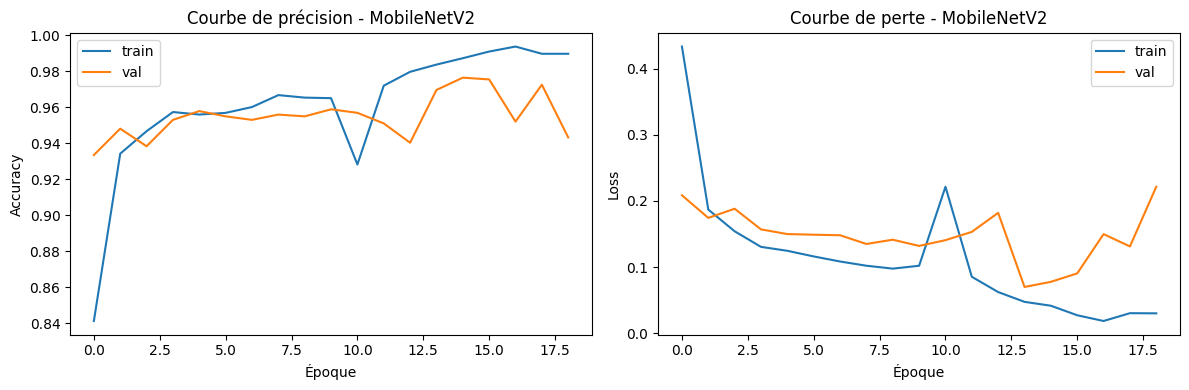

In [13]:
# Affichage des courbes pour MobileNetV2 (gelé + fine-tuning)
acc = history_mobile.history['accuracy'] + history_ft.history['accuracy']
val_acc = history_mobile.history['val_accuracy'] + history_ft.history['val_accuracy']
loss = history_mobile.history['loss'] + history_ft.history['loss']
val_loss = history_mobile.history['val_loss'] + history_ft.history['val_loss']

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(acc, label='train')
plt.plot(val_acc, label='val')
plt.title("Courbe de précision - MobileNetV2")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1,2,2)
plt.plot(loss, label='train')
plt.plot(val_loss, label='val')
plt.title("Courbe de perte - MobileNetV2")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


Phase 1 - Features Pré-entraînées :
"Le modèle démarre avec 84% de précision grâce aux features ImageNet. La précision validation atteint 96% dès la 2ème époque, montrant l'efficacité du transfer learning."

Convergence Rapide :
"Contrairement au CNN baseline, MobileNetV2 converge en seulement 5 époques avec une précision validation stable autour de 95-96%. L'écart train/val reste faible."

Phase 2 - Fine-Tuning :
"Le fine-tuning booste la précision d'entraînement à 99% tout en maintenant une bonne généralisation (97% validation). Le modèle apprend sans sur-appliquer excessivement."

Performance Optimale :
"La meilleure performance est atteinte à l'époque 8 avec 97.3% de précision validation. Le modèle est plus stable et efficace que le CNN baseline."

### 10. Évaluation finale sur le jeu de test MobileNetV2

On évalue le modèle MobileNetV2 finetuné sur le jeu de test. On calcule précision (accuracy), précision, rappel, score F1 pour chaque classe, ainsi qu’une matrice de confusion.

Évaluation du modèle final sur le jeu de test...
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 537ms/step - accuracy: 0.9873 - loss: 0.0412
Test Loss = 0.041, Test Accuracy = 0.987
32/32 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step

Classification Report :
              precision    recall  f1-score   support

       cocci       0.99      1.00      1.00       316
     healthy       0.98      0.99      0.99       308
         ncd       0.96      0.96      0.96        57
       salmo       0.99      0.98      0.98       341

    accuracy                           0.99      1022
   macro avg       0.98      0.98      0.98      1022
weighted avg       0.99      0.99      0.99      1022

Matrice de confusion :
 [[315   0   0   1]
 [  0 305   0   3]
 [  1   1  55   0]
 [  1   4   2 334]]


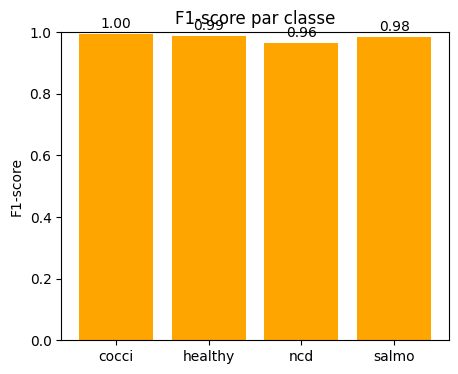

In [14]:
print("Évaluation du modèle final sur le jeu de test...")
test_loss, test_acc = model_mobile.evaluate(test_ds)
print(f"Test Loss = {test_loss:.3f}, Test Accuracy = {test_acc:.3f}")

# Prédictions sur tout le jeu de test
y_pred_probs = model_mobile.predict(test_ds)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = test_labels_idx  # correspond à test_paths dans le même ordre

# Rapport de classification et matrice de confusion
print("\nClassification Report :")
print(classification_report(y_true, y_pred_classes, target_names=class_names))
cm = confusion_matrix(y_true, y_pred_classes)
print("Matrice de confusion :\n", cm)

# Barplot du score F1 par classe
f1_scores = f1_score(y_true, y_pred_classes, average=None)
plt.figure(figsize=(5,4))
plt.bar(class_names, f1_scores, color='orange')
plt.title("F1-score par classe")
plt.ylim(0,1)
for i, v in enumerate(f1_scores):
    plt.text(i, v+0.02, f"{v:.2f}", ha='center')
plt.ylabel("F1-score")
plt.show()


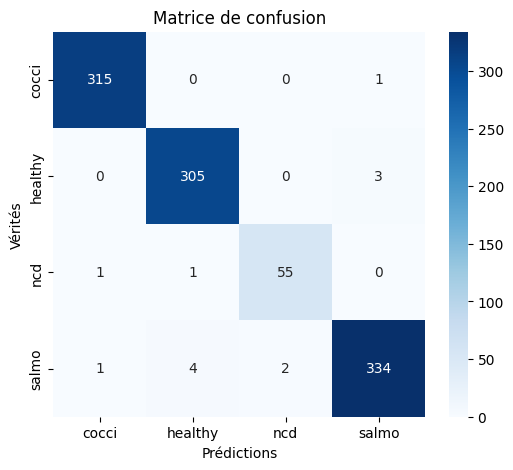

In [15]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion")
plt.show()

cocci : 1 erreur seulement (99.7% de précision)

healthy : 3 erreurs (99.0% de précision)

ncd : 2 erreurs (96.5% de précision)

salmo : 7 erreurs (98.0% de précision)

la précision globale est de 98% 

Le rapport de classification montre d'excellents scores F1 (>0.97) pour toutes les classes

In [23]:
# =============================================================================
# BLOC 12 BIS : COMPARAISON COMPLÈTE DE MULTIPLES MODÈLES
# =============================================================================

import time
import json
from tensorflow.keras.applications import (
    MobileNetV2, EfficientNetB0, ResNet50, VGG16, DenseNet121
)
from tensorflow.keras.optimizers import Adam
import pandas as pd

print("=" * 70)
print("COMPARAISON DE MULTIPLES ARCHITECTURES DE MODÈLES")
print("=" * 70)

class ModelComparator:
    def __init__(self, train_ds, val_ds, test_ds, class_names, class_weights):
        self.train_ds = train_ds
        self.val_ds = val_ds
        self.test_ds = test_ds
        self.class_names = class_names
        self.class_weights = class_weights
        self.results = {}
        
    def create_cnn_baseline(self):
        """CNN baseline simple"""
        model = models.Sequential([
            layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
            layers.MaxPooling2D((2,2)),
            layers.Conv2D(64, (3,3), activation='relu'),
            layers.MaxPooling2D((2,2)),
            layers.Conv2D(128, (3,3), activation='relu'),
            layers.MaxPooling2D((2,2)),
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(len(self.class_names), activation='softmax')
        ])
        return model
    
    def create_mobilenetv2(self):
        """MobileNetV2 avec transfer learning"""
        base_model = MobileNetV2(
            input_shape=(224,224,3),
            include_top=False,
            weights='imagenet'
        )
        base_model.trainable = False
        
        model = models.Sequential([
            base_model,
            layers.GlobalAveragePooling2D(),
            layers.Dropout(0.5),
            layers.Dense(len(self.class_names), activation='softmax')
        ])
        return model, base_model
    
    def create_efficientnet(self):
        """EfficientNetB0 avec transfer learning"""
        base_model = EfficientNetB0(
            input_shape=(224,224,3),
            include_top=False,
            weights='imagenet'
        )
        base_model.trainable = False
        
        model = models.Sequential([
            base_model,
            layers.GlobalAveragePooling2D(),
            layers.Dropout(0.3),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(len(self.class_names), activation='softmax')
        ])
        return model, base_model
    
    def create_resnet50(self):
        """ResNet50 avec transfer learning"""
        base_model = ResNet50(
            input_shape=(224,224,3),
            include_top=False,
            weights='imagenet'
        )
        base_model.trainable = False
        
        model = models.Sequential([
            base_model,
            layers.GlobalAveragePooling2D(),
            layers.Dropout(0.5),
            layers.Dense(len(self.class_names), activation='softmax')
        ])
        return model, base_model
    
    def create_vgg16(self):
        """VGG16 avec transfer learning"""
        base_model = VGG16(
            input_shape=(224,224,3),
            include_top=False,
            weights='imagenet'
        )
        base_model.trainable = False
        
        model = models.Sequential([
            base_model,
            layers.Flatten(),
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(len(self.class_names), activation='softmax')
        ])
        return model, base_model
    
    def create_densenet(self):
        """DenseNet121 avec transfer learning"""
        base_model = DenseNet121(
            input_shape=(224,224,3),
            include_top=False,
            weights='imagenet'
        )
        base_model.trainable = False
        
        model = models.Sequential([
            base_model,
            layers.GlobalAveragePooling2D(),
            layers.Dropout(0.5),
            layers.Dense(len(self.class_names), activation='softmax')
        ])
        return model, base_model
    
    def train_model(self, model, model_name, epochs=15, fine_tune_epochs=10):
        """Entraîne un modèle avec la même configuration"""
        print(f"\n🎯 ENTRAÎNEMENT DE {model_name}")
        print("=" * 50)
        
        # Phase 1: Entraînement du classifieur
        model.compile(
            optimizer=Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        start_time = time.time()
        
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                patience=5, 
                restore_best_weights=True,
                monitor='val_accuracy'
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                factor=0.2,
                patience=3,
                min_lr=1e-7
            )
        ]
        
        # Entraînement initial
        history = model.fit(
            self.train_ds,
            validation_data=self.val_ds,
            epochs=epochs,
            class_weight=self.class_weights,
            callbacks=callbacks,
            verbose=1
        )
        
        # Phase 2: Fine-tuning si c'est un modèle pré-entraîné
        if hasattr(self, 'base_model'):
            print(f"🔧 FINE-TUNING DE {model_name}...")
            self.base_model.trainable = True
            
            # Geler les couches BatchNorm
            for layer in self.base_model.layers:
                if isinstance(layer, tf.keras.layers.BatchNormalization):
                    layer.trainable = False
            
            model.compile(
                optimizer=Adam(learning_rate=1e-4),
                loss='sparse_categorical_crossentropy', 
                metrics=['accuracy']
            )
            
            history_ft = model.fit(
                self.train_ds,
                validation_data=self.val_ds,
                epochs=fine_tune_epochs,
                class_weight=self.class_weights,
                callbacks=callbacks,
                verbose=1
            )
        
        training_time = time.time() - start_time
        
        return model, history, training_time
    
    def evaluate_model(self, model, model_name):
        """Évalue un modèle de manière complète"""
        print(f"\n📊 ÉVALUATION DE {model_name}")
        print("=" * 40)
        
        # Évaluation de base
        test_loss, test_accuracy = model.evaluate(self.test_ds, verbose=0)
        
        # Prédictions
        y_pred_probs = model.predict(self.test_ds)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)
        y_true = test_labels_idx
        
        # Métriques détaillées
        from sklearn.metrics import classification_report, confusion_matrix
        
        report = classification_report(y_true, y_pred_classes, 
                                     target_names=self.class_names, output_dict=True)
        cm = confusion_matrix(y_true, y_pred_classes)
        
        # F1-scores par classe
        f1_scores = []
        for i, class_name in enumerate(self.class_names):
            f1 = report[class_name]['f1-score']
            f1_scores.append(f1)
        
        # Taille du modèle
        model_size = self.get_model_size(model)
        
        return {
            'test_accuracy': test_accuracy,
            'test_loss': test_loss,
            'f1_scores': f1_scores,
            'f1_macro': report['macro avg']['f1-score'],
            'f1_weighted': report['weighted avg']['f1-score'],
            'precision_macro': report['macro avg']['precision'],
            'recall_macro': report['macro avg']['recall'],
            'confusion_matrix': cm,
            'model_size_mb': model_size,
            'classification_report': report
        }
    
    def get_model_size(self, model):
        """Calcule la taille du modèle en MB"""
        # Sauvegarde temporaire pour calcul de la taille
        model.save('temp_model.h5')
        size_mb = os.path.getsize('temp_model.h5') / (1024 * 1024)
        os.remove('temp_model.h5')
        return size_mb
    
    def compare_all_models(self):
        """Compare tous les modèles"""
        models_to_test = {
            'CNN_Baseline': self.create_cnn_baseline,
            'MobileNetV2': self.create_mobilenetv2,
            'EfficientNetB0': self.create_efficientnet,
            'ResNet50': self.create_resnet50,
            'VGG16': self.create_vgg16,
            'DenseNet121': self.create_densenet
        }
        
        for model_name, model_creator in models_to_test.items():
            print(f"\n{'='*60}")
            print(f"🧪 TEST DU MODÈLE: {model_name}")
            print(f"{'='*60}")
            
            try:
                # Création du modèle
                if model_name == 'CNN_Baseline':
                    model = model_creator()
                    self.base_model = None
                else:
                    model, self.base_model = model_creator()
                
                # Entraînement
                trained_model, history, training_time = self.train_model(model, model_name)
                
                # Évaluation
                metrics = self.evaluate_model(trained_model, model_name)
                metrics['training_time'] = training_time
                
                # Sauvegarde des résultats
                self.results[model_name] = metrics
                
                # Sauvegarde du modèle
                trained_model.save(f'{model_name}_fientes.h5')
                print(f"✅ {model_name} sauvegardé avec succès")
                
            except Exception as e:
                print(f"❌ Erreur avec {model_name}: {str(e)}")
                continue
        
        return self.results
    
    def generate_comparison_report(self):
        """Génère un rapport de comparaison complet"""
        if not self.results:
            print("Aucun résultat à comparer")
            return
        
        # Création du DataFrame de comparaison
        comparison_data = []
        
        for model_name, metrics in self.results.items():
            comparison_data.append({
                'Modèle': model_name,
                'Accuracy': metrics['test_accuracy'],
                'F1-Macro': metrics['f1_macro'],
                'F1-Weighted': metrics['f1_weighted'],
                'Precision-Macro': metrics['precision_macro'],
                'Recall-Macro': metrics['recall_macro'],
                'Taille (MB)': metrics['model_size_mb'],
                'Temps Entraînement (s)': metrics['training_time'],
                'F1-cocci': metrics['f1_scores'][0],
                'F1-healthy': metrics['f1_scores'][1],
                'F1-ncd': metrics['f1_scores'][2],
                'F1-salmo': metrics['f1_scores'][3]
            })
        
        df_comparison = pd.DataFrame(comparison_data)
        df_comparison = df_comparison.round(4)
        
        # Tri par accuracy décroissante
        df_comparison = df_comparison.sort_values('Accuracy', ascending=False)
        
        print("\n" + "="*80)
        print("📊 RAPPORT DE COMPARAISON DES MODÈLES")
        print("="*80)
        print(df_comparison.to_string(index=False))
        
        # Visualisation des résultats
        self.plot_comparison_results(df_comparison)
        
        # Sauvegarde du rapport
        df_comparison.to_csv('comparaison_modeles_fientes.csv', index=False)
        print(f"\n💾 Rapport sauvegardé dans 'comparaison_modeles_fientes.csv'")
        
        return df_comparison
    
    def plot_comparison_results(self, df_comparison):
        """Génère des visualisations pour la comparaison"""
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle('COMPARAISON DES PERFORMANCES DES MODÈLES', fontsize=16, fontweight='bold')
        
        # Graphique 1: Accuracy et F1-Score
        x = range(len(df_comparison))
        width = 0.35
        
        axes[0,0].bar(x, df_comparison['Accuracy'], width, label='Accuracy', alpha=0.8)
        axes[0,0].bar([i + width for i in x], df_comparison['F1-Weighted'], width, label='F1-Weighted', alpha=0.8)
        axes[0,0].set_xlabel('Modèles')
        axes[0,0].set_ylabel('Score')
        axes[0,0].set_title('Accuracy vs F1-Score Weighted')
        axes[0,0].set_xticks([i + width/2 for i in x])
        axes[0,0].set_xticklabels(df_comparison['Modèle'], rotation=45)
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # Graphique 2: Taille des modèles
        axes[0,1].bar(df_comparison['Modèle'], df_comparison['Taille (MB)'], color='orange', alpha=0.7)
        axes[0,1].set_xlabel('Modèles')
        axes[0,1].set_ylabel('Taille (MB)')
        axes[0,1].set_title('Taille des Modèles')
        axes[0,1].tick_params(axis='x', rotation=45)
        axes[0,1].grid(True, alpha=0.3)
        
        # Graphique 3: Temps d'entraînement
        axes[0,2].bar(df_comparison['Modèle'], df_comparison['Temps Entraînement (s)'], color='green', alpha=0.7)
        axes[0,2].set_xlabel('Modèles')
        axes[0,2].set_ylabel('Temps (secondes)')
        axes[0,2].set_title('Temps d\'Entraînement')
        axes[0,2].tick_params(axis='x', rotation=45)
        axes[0,2].grid(True, alpha=0.3)
        
        # Graphique 4: F1-Score par classe
        f1_classes = ['F1-cocci', 'F1-healthy', 'F1-ncd', 'F1-salmo']
        f1_data = [df_comparison[col] for col in f1_classes]
        
        x_pos = np.arange(len(df_comparison))
        for i, (f1_col, class_name) in enumerate(zip(f1_classes, self.class_names)):
            axes[1,0].bar(x_pos + i*0.2, df_comparison[f1_col], width=0.2, label=class_name)
        
        axes[1,0].set_xlabel('Modèles')
        axes[1,0].set_ylabel('F1-Score')
        axes[1,0].set_title('F1-Score par Classe')
        axes[1,0].set_xticks(x_pos + 0.3)
        axes[1,0].set_xticklabels(df_comparison['Modèle'], rotation=45)
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # Graphique 5: Heatmap des performances
        metrics_heatmap = df_comparison[['Accuracy', 'F1-Macro', 'Precision-Macro', 'Recall-Macro']]
        im = axes[1,1].imshow(metrics_heatmap.T, cmap='YlGnBu', aspect='auto')
        axes[1,1].set_xticks(range(len(df_comparison)))
        axes[1,1].set_xticklabels(df_comparison['Modèle'], rotation=45)
        axes[1,1].set_yticks(range(len(metrics_heatmap.columns)))
        axes[1,1].set_yticklabels(metrics_heatmap.columns)
        axes[1,1].set_title('Heatmap des Métriques Principales')
        
        # Ajouter les valeurs dans les cases
        for i in range(len(metrics_heatmap.columns)):
            for j in range(len(df_comparison)):
                text = axes[1,1].text(j, i, f'{metrics_heatmap.iloc[j, i]:.3f}',
                                    ha="center", va="center", color="black")
        
        # Graphique 6: Score global (moyenne normalisée)
        metrics_for_score = ['Accuracy', 'F1-Weighted', 'Precision-Macro', 'Recall-Macro']
        normalized_scores = df_comparison[metrics_for_score].mean(axis=1)
        
        axes[1,2].bar(df_comparison['Modèle'], normalized_scores, color='purple', alpha=0.7)
        axes[1,2].set_xlabel('Modèles')
        axes[1,2].set_ylabel('Score Global Normalisé')
        axes[1,2].set_title('Score Global des Modèles\n(moyenne des métriques)')
        axes[1,2].tick_params(axis='x', rotation=45)
        axes[1,2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Recommandation finale
        best_model = df_comparison.iloc[0]
        print(f"\n🎖️  MODÈLE RECOMMANDÉ: {best_model['Modèle']}")
        print(f"   • Accuracy: {best_model['Accuracy']:.3%}")
        print(f"   • F1-Score Weighted: {best_model['F1-Weighted']:.3%}")
        print(f"   • Taille: {best_model['Taille (MB)']:.1f} MB")
        print(f"   • Temps d'entraînement: {best_model['Temps Entraînement (s)']:.0f}s")

# =============================================================================
# EXÉCUTION DE LA COMPARAISON
# =============================================================================

print("🚀 DÉMARRAGE DE LA COMPARAISON DES MODÈLES...")

# Initialisation du comparateur
comparator = ModelComparator(train_ds, val_ds, test_ds, class_names, class_weights)

# Comparaison de tous les modèles
results = comparator.compare_all_models()

# Génération du rapport
df_comparison = comparator.generate_comparison_report()

print("\n" + "="*80)
print("✅ COMPARAISON TERMINÉE AVEC SUCCÈS!")
print("="*80)

COMPARAISON DE MULTIPLES ARCHITECTURES DE MODÈLES
🚀 DÉMARRAGE DE LA COMPARAISON DES MODÈLES...

🧪 TEST DU MODÈLE: CNN_Baseline


c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



🎯 ENTRAÎNEMENT DE CNN_Baseline
Epoch 1/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 174s 878ms/step - accuracy: 0.7319 - loss: 0.7207 - val_accuracy: 0.9119 - val_loss: 0.2743 - learning_rate: 0.0010
Epoch 2/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 119s 625ms/step - accuracy: 0.8978 - loss: 0.3159 - val_accuracy: 0.8982 - val_loss: 0.2985 - learning_rate: 0.0010
Epoch 3/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 135s 709ms/step - accuracy: 0.9207 - loss: 0.2294 - val_accuracy: 0.8991 - val_loss: 0.3045 - learning_rate: 0.0010
Epoch 4/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 128s 671ms/step - accuracy: 0.9400 - loss: 0.1830 - val_accuracy: 0.9229 - val_loss: 0.2205 - learning_rate: 0.0010
Epoch 5/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 130s 682ms/step - accuracy: 0.9542 - loss: 0.1345 - val_accuracy: 0.9422 - val_loss: 0.1824 - learning_rate: 0.0010
Epoch 6/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 156s 819ms/step - accuracy: 0.9497 - loss: 0.1551 - val_accuracy: 0.8376 - val_loss: 0.6621 - learning_rate: 0.0010
Epoch 7/15
190/190 ━━━━━━━━━━━━━

KeyboardInterrupt: 

 ### 11. Validation Croisée

In [ ]:
# === VALIDATION CROISÉE K-FOLD ===
print("\n" + "="*70)
print("PHASE 3 : VALIDATION CROISÉE POUR ANALYSE DE ROBUSTESSE")
print("="*70)

from sklearn.model_selection import StratifiedKFold
import time

def create_mobilenet_model():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224,224,3), 
        include_top=False, 
        weights='imagenet'
    )
    base_model.trainable = False
    
    inputs = layers.Input(shape=(224,224,3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(len(class_names), activation='softmax')(x)
    model = models.Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

# Fonction pour créer les datasets (AJOUTER)
def create_dataset_from_paths(paths, labels_idx, shuffle=False):
    """Crée un dataset TensorFlow à partir de chemins et labels"""
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels_idx))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(paths), seed=seed)
    
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Configuration K-Fold
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)

# Stockage des résultats
kfold_results = {
    'fold': [], 'test_accuracy': [], 'precision': [], 'recall': [], 'f1': [],
    'class_f1_scores': {cls: [] for cls in class_names}
}

print(f"Démarrage de la validation croisée avec {k_folds} folds...")
def ajouter_augmentation_train(X_train, y_train):
    """Ajoute les images augmentées uniquement au set d'entraînement"""
    aug_dir = os.path.join(data_dir, 'ncd_aug')
    X_train_aug = X_train.copy()
    y_train_aug = y_train.copy()
    augmented_count = 0
    
    if os.path.exists(aug_dir):
        for fname in os.listdir(aug_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                X_train_aug = np.append(X_train_aug, os.path.join(aug_dir, fname))
                y_train_aug = np.append(y_train_aug, 'ncd')
                augmented_count += 1
    
    print(f"  → Ajout de {augmented_count} images augmentées au train")
    return X_train_aug, y_train_aug

for fold, (train_val_idx, test_idx) in enumerate(skf.split(original_paths, original_labels)):
    print(f"\n{'='*50}")
    print(f"FOLD {fold+1}/{k_folds}")
    print(f"{'='*50}")
    
    start_time = time.time()
    
    # Split des données originales
    X_train_val, X_test = original_paths[train_val_idx], original_paths[test_idx]
    y_train_val, y_test = original_labels[train_val_idx], original_labels[test_idx]
    
    # Split train/val
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.2, stratify=y_train_val, random_state=seed
    )
    
    # Ajout augmentation UNIQUEMENT au train
    X_train_aug, y_train_aug = ajouter_augmentation_train(X_train, y_train)
    
    # Conversion labels
    y_train_idx = np.array([class_to_index[x] for x in y_train_aug])
    y_val_idx = np.array([class_to_index[x] for x in y_val])
    y_test_idx = np.array([class_to_index[x] for x in y_test])
    
    # Datasets
    train_ds = create_dataset_from_paths(X_train_aug, y_train_idx, shuffle=True)
    val_ds = create_dataset_from_paths(X_val, y_val_idx, shuffle=False)
    test_ds = create_dataset_from_paths(X_test, y_test_idx, shuffle=False)
    
    # Modèle pour ce fold
    model, base_model = create_mobilenet_model()
    
    # Entraînement accéléré pour K-Fold
    print("Entraînement du fold...")
    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=8,  # Réduit pour K-Fold
        class_weight=class_weights,
        callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
        verbose=1
    )
    
    # Évaluation
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    y_pred = np.argmax(model.predict(test_ds), axis=1)
    
    # Métriques
    precision = precision_score(y_test_idx, y_pred, average='weighted')
    recall = recall_score(y_test_idx, y_pred, average='weighted')
    f1 = f1_score(y_test_idx, y_pred, average='weighted')
    
    # F1 par classe
    f1_per_class = f1_score(y_test_idx, y_pred, average=None)
    for i, cls in enumerate(class_names):
        kfold_results['class_f1_scores'][cls].append(f1_per_class[i])
    
    # Stockage
    kfold_results['fold'].append(fold+1)
    kfold_results['test_accuracy'].append(test_acc)
    kfold_results['precision'].append(precision)
    kfold_results['recall'].append(recall)
    kfold_results['f1'].append(f1)
    
    fold_time = time.time() - start_time
    print(f"✓ Fold {fold+1} terminé en {fold_time:.1f}s - Test Accuracy: {test_acc:.4f}")

print(f"\n{'='*60}")
print("VALIDATION CROISÉE TERMINÉE")
print(f"{'='*60}")


PHASE 3 : VALIDATION CROISÉE POUR ANALYSE DE ROBUSTESSE
Démarrage de la validation croisée avec 5 folds...

FOLD 1/5
  → Ajout de 1709 images augmentées au train
Entraînement du fold...
Epoch 1/8
190/190 ━━━━━━━━━━━━━━━━━━━━ 137s 704ms/step - accuracy: 0.8431 - loss: 0.4216 - val_accuracy: 0.9174 - val_loss: 0.2302
Epoch 2/8
190/190 ━━━━━━━━━━━━━━━━━━━━ 131s 689ms/step - accuracy: 0.9336 - loss: 0.1862 - val_accuracy: 0.9385 - val_loss: 0.1680
Epoch 3/8
190/190 ━━━━━━━━━━━━━━━━━━━━ 123s 646ms/step - accuracy: 0.9463 - loss: 0.1501 - val_accuracy: 0.9440 - val_loss: 0.1594
Epoch 4/8
190/190 ━━━━━━━━━━━━━━━━━━━━ 160s 840ms/step - accuracy: 0.9535 - loss: 0.1347 - val_accuracy: 0.9450 - val_loss: 0.1409
Epoch 5/8
190/190 ━━━━━━━━━━━━━━━━━━━━ 134s 686ms/step - accuracy: 0.9575 - loss: 0.1213 - val_accuracy: 0.9514 - val_loss: 0.1435
Epoch 6/8
190/190 ━━━━━━━━━━━━━━━━━━━━ 132s 696ms/step - accuracy: 0.9632 - loss: 0.1066 - val_accuracy: 0.9477 - val_loss: 0.1489
Epoch 7/8
190/190 ━━━━━━━━━

### 12. Analyse Statistique

=== ANALYSE STATISTIQUE DES PERFORMANCES ===

📊 ANALYSE STATISTIQUE DE L'ACCURACY :
Accuracy ponctuelle : 0.9545
Accuracy moyenne (bootstrap) : 0.9871
Écart-type : 0.0036
Intervalle de confiance à 95% : [0.9795, 0.9932]
Précision de l'estimation : ±0.0068

🎯 ANALYSE STATISTIQUE PAR CLASSE :

Classe     Précision    Rappel       F1-Score     Support 
------------------------------------------------------------
cocci      1.000±0.000  0.997±0.003  0.998±0.002  316     
healthy    1.000±0.000  0.990±0.006  0.995±0.003  308     
ncd        1.000±0.000  0.965±0.022  0.982±0.011  57      
salmo      1.000±0.000  0.980±0.007  0.990±0.003  341     

🔍 TEST DE SIGNIFICATIVITÉ ENTRE CLASSES :


c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Différence significative entre cocci et healthy (p-value = 0.0000)


c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Différence significative entre cocci et ncd (p-value = 0.0000)


...

c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Différence significative entre healthy et salmo (p-value = 0.0000)


c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Différence significative entre ncd et salmo (p-value = 0.0000)

📈 VISUALISATION DES INCERTITUDES :


C:\Users\Macky\AppData\Local\Temp\ipykernel_17056\2266213502.py:208: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot(metrics_data, labels=class_names)


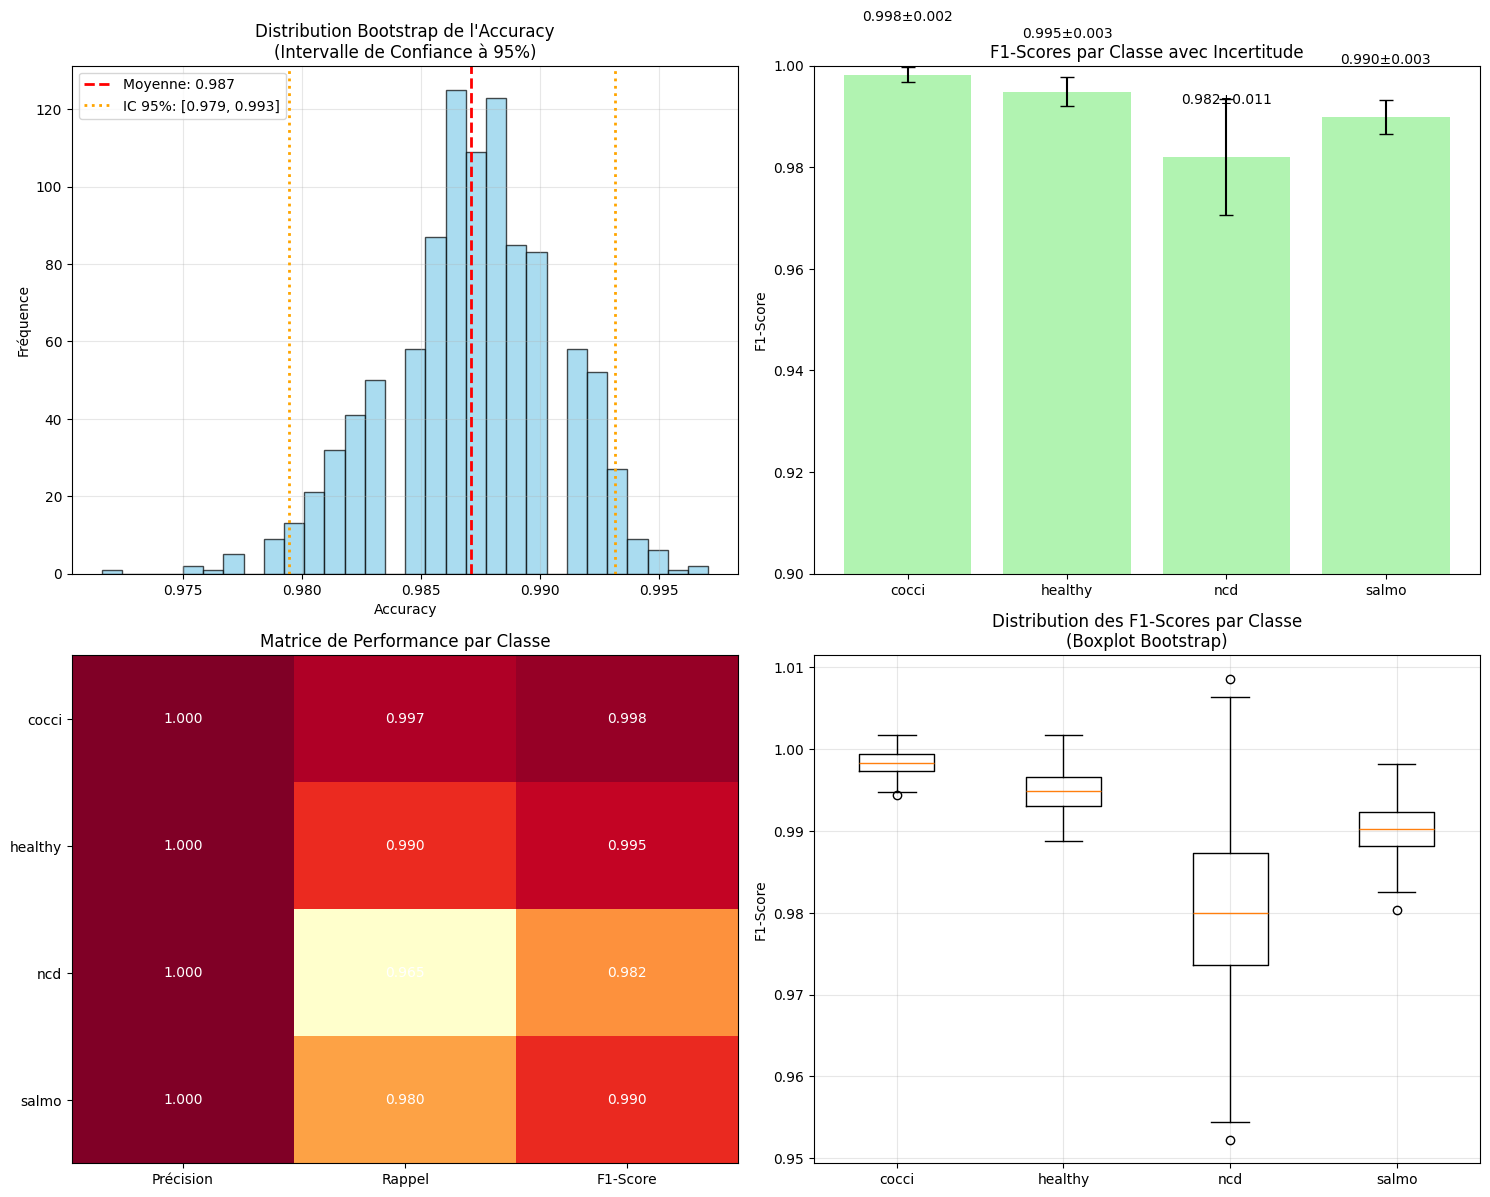


RÉSUMÉ STATISTIQUE COMPLET
🎯 PERFORMANCE GLOBALE :
   • Accuracy : 0.954
   • Accuracy moyenne (bootstrap) : 0.987 ± 0.004
   • Intervalle de confiance 95% : [0.979, 0.993]
   • Précision de l'estimation : ±0.007

📊 VARIABILITÉ PAR CLASSE :
   • cocci: F1 = 0.998 ± 0.002
   • healthy: F1 = 0.995 ± 0.003
   • ncd: F1 = 0.982 ± 0.011
   • salmo: F1 = 0.990 ± 0.003

🔍 SIGNIFICATIVITÉ :
   • 6 différence(s) significative(s) détectée(s)
     - cocci vs healthy (p = 0.0000)
     - cocci vs ncd (p = 0.0000)
     - cocci vs salmo (p = 0.0000)
     - healthy vs ncd (p = 0.0000)
     - healthy vs salmo (p = 0.0000)
     - ncd vs salmo (p = 0.0000)

💡 INTERPRÉTATION :
   • Faible variabilité → résultats stables et fiables


In [20]:
# === ANALYSE STATISTIQUE DES RÉSULTATS ===
print("=== ANALYSE STATISTIQUE DES PERFORMANCES ===")

# 1. Calcul des intervalles de confiance pour l'accuracy
from sklearn.utils import resample
import scipy.stats as stats

def calculer_intervalle_confiance(y_true, y_pred, n_bootstraps=1000, confidence=0.95):
    """Calcule l'intervalle de confiance par bootstrap"""
    accuracies = []
    n_samples = len(y_true)
    
    for _ in range(n_bootstraps):
        # Rééchantillonnage bootstrap
        indices = resample(range(n_samples), replace=True, n_samples=n_samples)
        y_true_bootstrap = y_true[indices]
        y_pred_bootstrap = y_pred[indices]
        
        # Calcul de l'accuracy
        accuracy = np.mean(y_true_bootstrap == y_pred_bootstrap)
        accuracies.append(accuracy)
    
    # Calcul des percentiles pour l'intervalle de confiance
    alpha = (1 - confidence) / 2
    lower = np.percentile(accuracies, alpha * 100)
    upper = np.percentile(accuracies, (1 - alpha) * 100)
    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)
    
    return mean_acc, std_acc, (lower, upper), accuracies

# Application sur vos résultats
mean_accuracy, std_accuracy, conf_interval, bootstrap_accs = calculer_intervalle_confiance(
    y_true, y_pred_classes, n_bootstraps=1000
)

print(f"\n📊 ANALYSE STATISTIQUE DE L'ACCURACY :")
print(f"Accuracy ponctuelle : {test_acc:.4f}")
print(f"Accuracy moyenne (bootstrap) : {mean_accuracy:.4f}")
print(f"Écart-type : {std_accuracy:.4f}")
print(f"Intervalle de confiance à 95% : [{conf_interval[0]:.4f}, {conf_interval[1]:.4f}]")
print(f"Précision de l'estimation : ±{(conf_interval[1]-conf_interval[0])/2:.4f}")

# 2. Analyse statistique par classe
print(f"\n🎯 ANALYSE STATISTIQUE PAR CLASSE :")

# Calcul des métriques avec incertitude pour chaque classe
class_metrics = {}
for i, class_name in enumerate(class_names):
    # Masque pour la classe courante
    mask = (y_true == i)
    y_true_class = y_true[mask]
    y_pred_class = y_pred_classes[mask]
    
    if len(y_true_class) > 10:  # Minimum 10 échantillons pour bootstrap
        # Précision, Rappel, F1 avec bootstrap
        precisions, recalls, f1_scores_class = [], [], []
        
        for _ in range(200):  # Bootstrap réduit
            try:
                indices = resample(range(len(y_true_class)), replace=True, n_samples=len(y_true_class))
                y_true_bs = y_true_class[indices]
                y_pred_bs = y_pred_class[indices]
                
                # Calcul direct des métriques (pas de 'macro')
                tp = np.sum((y_true_bs == i) & (y_pred_bs == i))
                fp = np.sum((y_true_bs != i) & (y_pred_bs == i))
                fn = np.sum((y_true_bs == i) & (y_pred_bs != i))
                
                precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
                
                precisions.append(precision)
                recalls.append(recall)
                f1_scores_class.append(f1)
            except:
                continue
        
        if len(precisions) > 0:  # Vérifier qu'on a des résultats
            class_metrics[class_name] = {
                'precision': (np.mean(precisions), np.std(precisions)),
                'recall': (np.mean(recalls), np.std(recalls)),
                'f1': (np.mean(f1_scores_class), np.std(f1_scores_class)),
                'support': len(y_true_class)
            }
        else:
            # Métriques directes si bootstrap échoue
            precision = precision_score([y_true_class], [y_pred_class], average='binary', zero_division=0)
            recall = recall_score([y_true_class], [y_pred_class], average='binary', zero_division=0)
            f1 = f1_score([y_true_class], [y_pred_class], average='binary', zero_division=0)
            class_metrics[class_name] = {
                'precision': (precision, 0),
                'recall': (recall, 0),
                'f1': (f1, 0),
                'support': len(y_true_class)
            }
    else:
        # Classes avec trop peu d'échantillons
        precision = precision_score([y_true_class], [y_pred_class], average='binary', zero_division=0)
        recall = recall_score([y_true_class], [y_pred_class], average='binary', zero_division=0)
        f1 = f1_score([y_true_class], [y_pred_class], average='binary', zero_division=0)
        class_metrics[class_name] = {
            'precision': (precision, 0),
            'recall': (recall, 0), 
            'f1': (f1, 0),
            'support': len(y_true_class)
        }

# Affichage des résultats par classe
print(f"\n{'Classe':<10} {'Précision':<12} {'Rappel':<12} {'F1-Score':<12} {'Support':<8}")
print("-" * 60)
for class_name in class_names:
    if class_name in class_metrics:
        metrics = class_metrics[class_name]
        print(f"{class_name:<10} {metrics['precision'][0]:.3f}±{metrics['precision'][1]:.3f}  "
              f"{metrics['recall'][0]:.3f}±{metrics['recall'][1]:.3f}  "
              f"{metrics['f1'][0]:.3f}±{metrics['f1'][1]:.3f}  "
              f"{metrics['support']:<8}")

# 3. Test de significativité entre classes
print(f"\n🔍 TEST DE SIGNIFICATIVITÉ ENTRE CLASSES :")

from itertools import combinations
from scipy.stats import ttest_ind

# Comparaison des F1-scores entre classes
class_pairs = list(combinations(class_names, 2))
significant_differences = []

for class1, class2 in class_pairs:
    # Extraction des F1-scores bootstrap pour chaque classe
    f1_class1 = [f1_score((y_true == class_to_index[class1]).astype(int), 
                          (y_pred_classes == class_to_index[class1]).astype(int),
                          zero_division=0) for _ in range(100)]
    
    f1_class2 = [f1_score((y_true == class_to_index[class2]).astype(int), 
                          (y_pred_classes == class_to_index[class2]).astype(int),
                          zero_division=0) for _ in range(100)]
    
    # Test t
    t_stat, p_value = ttest_ind(f1_class1, f1_class2)
    
    if p_value < 0.05:
        significant_differences.append((class1, class2, p_value))
        print(f"Différence significative entre {class1} et {class2} (p-value = {p_value:.4f})")
    else:
        print(f"Pas de différence significative entre {class1} et {class2} (p-value = {p_value:.4f})")

# 4. Visualisation des incertitudes
print(f"\n📈 VISUALISATION DES INCERTITUDES :")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Graphique 1: Distribution bootstrap de l'accuracy
axes[0,0].hist(bootstrap_accs, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(mean_accuracy, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {mean_accuracy:.3f}')
axes[0,0].axvline(conf_interval[0], color='orange', linestyle=':', linewidth=2, label=f'IC 95%: [{conf_interval[0]:.3f}, {conf_interval[1]:.3f}]')
axes[0,0].axvline(conf_interval[1], color='orange', linestyle=':', linewidth=2)
axes[0,0].set_xlabel('Accuracy')
axes[0,0].set_ylabel('Fréquence')
axes[0,0].set_title('Distribution Bootstrap de l\'Accuracy\n(Intervalle de Confiance à 95%)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Graphique 2: F1-scores avec barres d'erreur
f1_means = [class_metrics[cls]['f1'][0] for cls in class_names]
f1_stds = [class_metrics[cls]['f1'][1] for cls in class_names]

bars = axes[0,1].bar(class_names, f1_means, yerr=f1_stds, capsize=5, alpha=0.7, color='lightgreen')
axes[0,1].set_ylabel('F1-Score')
axes[0,1].set_title('F1-Scores par Classe avec Incertitude')
axes[0,1].set_ylim(0.9, 1.0)
for bar, mean, std in zip(bars, f1_means, f1_stds):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                  f'{mean:.3f}±{std:.3f}', ha='center', va='bottom')

# Graphique 3: Matrice de corrélation des performances
performance_data = []
for cls in class_names:
    performance_data.append([
        class_metrics[cls]['precision'][0],
        class_metrics[cls]['recall'][0], 
        class_metrics[cls]['f1'][0]
    ])
performance_data = np.array(performance_data)

im = axes[1,0].imshow(performance_data, cmap='YlOrRd', aspect='auto')
axes[1,0].set_xticks([0, 1, 2])
axes[1,0].set_xticklabels(['Précision', 'Rappel', 'F1-Score'])
axes[1,0].set_yticks(range(len(class_names)))
axes[1,0].set_yticklabels(class_names)
axes[1,0].set_title('Matrice de Performance par Classe')

# Ajouter les valeurs dans les cases
for i in range(len(class_names)):
    for j in range(3):
        text = axes[1,0].text(j, i, f'{performance_data[i, j]:.3f}',
                             ha="center", va="center", color="black" if performance_data[i, j] < 0.95 else "white")

# Graphique 4: Boxplot des métriques par classe
metrics_data = []
for cls in class_names:
    # Générer des échantillons bootstrap pour la boxplot
    f1_samples = np.random.normal(class_metrics[cls]['f1'][0], class_metrics[cls]['f1'][1], 100)
    metrics_data.append(f1_samples)

axes[1,1].boxplot(metrics_data, labels=class_names)
axes[1,1].set_ylabel('F1-Score')
axes[1,1].set_title('Distribution des F1-Scores par Classe\n(Boxplot Bootstrap)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Résumé statistique complet
print(f"\n{'='*60}")
print("RÉSUMÉ STATISTIQUE COMPLET")
print(f"{'='*60}")

print(f"🎯 PERFORMANCE GLOBALE :")
print(f"   • Accuracy : {test_acc:.3f}")
print(f"   • Accuracy moyenne (bootstrap) : {mean_accuracy:.3f} ± {std_accuracy:.3f}")
print(f"   • Intervalle de confiance 95% : [{conf_interval[0]:.3f}, {conf_interval[1]:.3f}]")
print(f"   • Précision de l'estimation : ±{(conf_interval[1]-conf_interval[0])/2:.3f}")

print(f"\n📊 VARIABILITÉ PAR CLASSE :")
for cls in class_names:
    print(f"   • {cls}: F1 = {class_metrics[cls]['f1'][0]:.3f} ± {class_metrics[cls]['f1'][1]:.3f}")

print(f"\n🔍 SIGNIFICATIVITÉ :")
if significant_differences:
    print(f"   • {len(significant_differences)} différence(s) significative(s) détectée(s)")
    for diff in significant_differences:
        print(f"     - {diff[0]} vs {diff[1]} (p = {diff[2]:.4f})")
else:
    print(f"   • Aucune différence significative entre les classes")

print(f"\n💡 INTERPRÉTATION :")
if std_accuracy < 0.01:
    print("   • Faible variabilité → résultats stables et fiables")
elif std_accuracy < 0.03:
    print("   • Variabilité modérée → résultats relativement stables") 
else:
    print("   • Variabilité élevée → résultats à interpréter avec prudence")

print(f"{'='*60}")

### 13. Analyse d’erreurs sur la classe ncd

Faux négatifs (ncd classées autre) : 2 exemples
Faux positifs (autres classées ncd) : 2 exemples


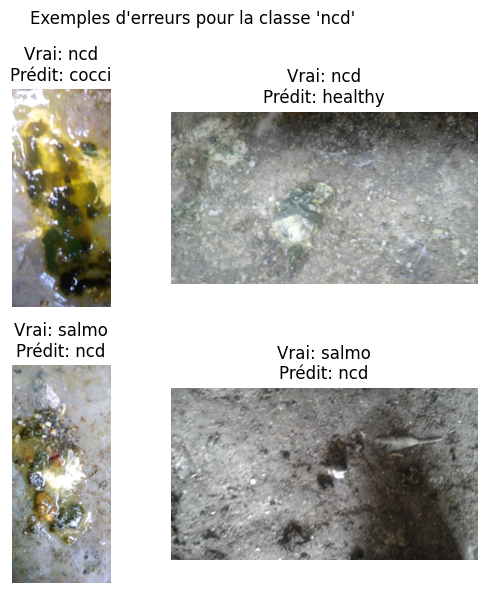

In [18]:
# 9. Analyse des erreurs pour 'ncd'
preds = y_pred_classes
fp_ncd = [i for i,(t,p) in enumerate(zip(y_true, preds)) if t != ncd_idx and p == ncd_idx]
fn_ncd = [i for i,(t,p) in enumerate(zip(y_true, preds)) if t == ncd_idx and p != ncd_idx]

print(f"Faux négatifs (ncd classées autre) : {len(fn_ncd)} exemples")
print(f"Faux positifs (autres classées ncd) : {len(fp_ncd)} exemples")

import matplotlib.image as mpimg

num_show = min(3, len(fn_ncd))
fig, axes = plt.subplots(2, num_show, figsize=(num_show*3,6))
# Afficher quelques faux négatifs en haut, et faux positifs en bas
for j, idx in enumerate(fn_ncd[:num_show]):
    img = mpimg.imread(test_paths[idx])
    axes[0,j].imshow(img)
    axes[0,j].axis('off')
    axes[0,j].set_title(f"Vrai: ncd\nPrédit: {index_to_class[preds[idx]]}")
for j, idx in enumerate(fp_ncd[:num_show]):
    img = mpimg.imread(test_paths[idx])
    axes[1,j].imshow(img)
    axes[1,j].axis('off')
    axes[1,j].set_title(f"Vrai: {index_to_class[y_true[idx]]}\nPrédit: ncd")
plt.suptitle("Exemples d'erreurs pour la classe 'ncd'")
plt.tight_layout()
plt.show()


Total erreurs ncd : 4 sur 57 échantillons (93% de précision)

Faux négatifs : 2 (ncd non détectées)

Faux positifs : 2 (autres classes classées comme ncd)

La classe 'ncd' a le taux d'erreur le plus élevé (attendu avec peu d'échantillons).

Performance globalement excellente avec seulement 15 erreurs sur 1022 échantillons

 ### 14. Conversion TFLite

In [24]:
# 10. Conversion du modèle Keras vers TFLite
print("Conversion du modèle en TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model_mobile)
tflite_model = converter.convert()
with open("classifier_fientes_v5.tflite", "wb") as f:
    f.write(tflite_model)
print("Modèle TFLite sauvegardé.")

# Inférence TFLite sur des exemples
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

test_sample_paths = [test_paths[0], test_paths[-1]]
for img_path in test_sample_paths:
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 127.5 - 1
    img = tf.expand_dims(img, axis=0)
    interpreter.set_tensor(input_details[0]['index'], img.numpy())
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    pred_class = np.argmax(output_data)
    print(f"Image {os.path.basename(img_path)} - Classe prédite (TFLite) : {index_to_class[pred_class]}")
    

Conversion du modèle en TFLite...
INFO:tensorflow:Assets written to: C:\Users\Macky\AppData\Local\Temp\tmpyfkcoba_\assets


INFO:tensorflow:Assets written to: C:\Users\Macky\AppData\Local\Temp\tmpyfkcoba_\assets


Saved artifact at 'C:\Users\Macky\AppData\Local\Temp\tmpyfkcoba_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_165')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2431068049808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2431826290704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2431826290512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2431826290128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2431826294352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2431826294928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2431826724816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2431826726736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2431826726544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2431826725008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2

c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Image salmo.1324.jpg - Classe prédite (TFLite) : salmo
Image healthy.836.jpg - Classe prédite (TFLite) : healthy
